# Imports

In [1]:
import pandas as pd
import cv2
import numpy as np

from ultralytics import YOLO
from matplotlib import pyplot as plt
from PIL import Image
import seaborn as sns

from cv2 import THRESH_BINARY
from cv2 import imread, imwrite, resize, cvtColor, threshold
# from sklearn.cluster import KMeans
from collections import Counter
from scipy.stats import pearsonr, spearmanr

# Loading File

In [ ]:
best_model = YOLO("/home/mrajaraman/master-thesis-dragonfly/yolo-model/runs/segment/train64/weights/best.pt")    
symph_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/geo_statistics/netherlands_symphetrum_striolatum_occurrences_full.csv")
test_images = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/symph.csv")

In [ ]:
test_image_path = test_images['Path'][5] #8432 is good example

dataframe_results = pd.DataFrame(columns=['ID','RGB_Abdomen','RGB_Thorax','RGB_Head','HSV_Abdomen','HSV_Thorax','HSV_Head'])


In [ ]:
results_improved = best_model(test_image_path, classes=[0,1,2], save=True)
image_id = test_image_path.split("/")[-1].split(".")[0]

r = results_improved[0]
boxes = r.boxes
classes = boxes.cls.cpu().tolist()
masks = r.masks

class_names = r.names
class_ids = r.boxes.cls.cpu().numpy().astype(int)
counter = Counter(class_ids)
output = [(class_names[k], v) for k, v in counter.items()]

test_image = cv2.imread(test_image_path)
img = cvtColor(test_image, cv2.COLOR_BGR2RGB)

In [ ]:
# dataframe_results = pd.DataFrame(columns=['ID','RGB_Abdomen','RGB_Thorax','RGB_Head','HSV_Abdomen','HSV_Thorax','HSV_Head'])
dataframe_results.loc[image_id] = [None] * len(dataframe_results.columns)

for item_name, item_count in output:
    if item_name == 'tail' and item_count == 1:
        corresponding_index = [key for key, value in class_names.items() if value == item_name][0]
        tail_class_id = [k for k, v in class_names.items() if v == 'tail'][0]
        tail_indices = [i for i, c in enumerate(r.boxes.cls) if int(c) == tail_class_id]
        det_idx = tail_indices[0]
        corresponding_mask = r.masks.data[det_idx]

        part_mask = corresponding_mask.cpu().numpy()
        part_resized = cv2.resize(part_mask, (test_image.shape[1], test_image.shape[0])) #, interpolation=cv2.INTER_NEAREST)
        mask_uint = (part_resized * 255).astype(np.uint8)
        _, mask_binary = cv2.threshold(mask_uint, 127, 255, cv2.THRESH_BINARY)
        resultant_part = cv2.bitwise_and(img, img, mask=mask_binary)
        mask_colored = np.any(resultant_part != 0, axis=2)
        colored_pixels = resultant_part[mask_colored]

        mean_rgb = colored_pixels.mean(axis=(0))
        mean_rgb_img = mean_rgb.reshape(1, 1, 3).astype(np.uint8)
        mean_rgb_value = mean_rgb_img.tolist()[0][0]
        dataframe_results.at[image_id,'RGB_Abdomen'] = tuple(mean_rgb_value)
        hsv_frame = cv2.cvtColor(mean_rgb_img, cv2.COLOR_RGB2HSV).tolist()[0][0]
        dataframe_results.at[image_id,'HSV_Abdomen'] = tuple(hsv_frame)

    elif item_name == 'torso' and item_count == 1:
        corresponding_index = [key for key, value in class_names.items() if value == item_name][0]
        torso_class_id = [k for k, v in class_names.items() if v == 'torso'][0]
        torso_index = [i for i, c in enumerate(r.boxes.cls) if int(c) == torso_class_id]
        det_idx = torso_index[0]
        corresponding_mask = r.masks.data[det_idx]

        part_mask = corresponding_mask.cpu().numpy()
        part_resized = cv2.resize(part_mask, (test_image.shape[1], test_image.shape[0])) #, interpolation=cv2.INTER_NEAREST)
        mask_uint = (part_resized * 255).astype(np.uint8)
        _, mask_binary = cv2.threshold(mask_uint, 127, 255, cv2.THRESH_BINARY)
        resultant_part = cv2.bitwise_and(img, img, mask=mask_binary)
        mask_colored = np.any(resultant_part != 0, axis=2)
        colored_pixels = resultant_part[mask_colored]

        mean_rgb = colored_pixels.mean(axis=(0))
        mean_rgb_img = mean_rgb.reshape(1, 1, 3).astype(np.uint8)
        mean_rgb_value = mean_rgb_img.tolist()[0][0]
        dataframe_results.at[image_id,'RGB_Thorax'] = tuple(mean_rgb_value)
        hsv_frame = cv2.cvtColor(mean_rgb_img, cv2.COLOR_RGB2HSV).tolist()[0][0]
        dataframe_results.at[image_id,'HSV_Thorax']  = tuple(hsv_frame)
    
    elif item_name == 'head' and item_count == 1:
        corresponding_index = [key for key, value in class_names.items() if value == item_name][0]
        head_class_id = [k for k, v in class_names.items() if v == 'head'][0]
        head_index = [i for i, c in enumerate(r.boxes.cls) if int(c) == head_class_id]
        det_idx = head_index[0]
        corresponding_mask = r.masks.data[det_idx]

        part_mask = corresponding_mask.cpu().numpy()
        part_resized = cv2.resize(part_mask, (test_image.shape[1], test_image.shape[0])) #, interpolation=cv2.INTER_NEAREST)
        mask_uint = (part_resized * 255).astype(np.uint8)
        _, mask_binary = cv2.threshold(mask_uint, 127, 255, cv2.THRESH_BINARY)
        resultant_part = cv2.bitwise_and(img, img, mask=mask_binary)
        mask_colored = np.any(resultant_part != 0, axis=2)
        colored_pixels = resultant_part[mask_colored]

        mean_rgb = colored_pixels.mean(axis=(0))
        mean_rgb_img = mean_rgb.reshape(1, 1, 3).astype(np.uint8)
        mean_rgb_value = mean_rgb_img.tolist()[0][0]
        dataframe_results.at[image_id,'RGB_Head'] = tuple(mean_rgb_value)
        hsv_frame = cv2.cvtColor(mean_rgb_img, cv2.COLOR_RGB2HSV).tolist()[0][0]
        dataframe_results.at[image_id,'HSV_Head']  = tuple(hsv_frame)
    else:
        print(f"Unexpected item: {image_id} with count {item_count}")

# Color Correlation

## Preparing the dataframe

In [2]:
averages_csv = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/yolo-model/color_extraction/color_extraction_means.csv")
symph_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/geo_statistics/netherlands_symphetrum_striolatum_occurrences_full.csv")

In [3]:
averages_csv['index'] = averages_csv['index'].str.replace('img_', '')
averages_csv.drop('ID', axis=1, inplace=True)

In [4]:
# averages_csv.shape

In [5]:
# averages_csv.head(5)

In [6]:
# averages_csv = averages_csv.dropna(subset=['RGB_Abdomen','RGB_Thorax','RGB_Head','HSV_Abdomen','HSV_Thorax','HSV_Head'], how='all')
averages_csv_any = averages_csv.dropna(subset=['RGB_Abdomen','RGB_Thorax','RGB_Head','HSV_Abdomen','HSV_Thorax','HSV_Head'], how='any')

# print(f"Shape of general averages is {averages_csv.shape} and when all values of NA are removed are {averages_csv_any.shape}")


In [7]:
# symph_df.head(5)

In [8]:
# averages_csv['index'] = averages_csv['index'].astype(int)
averages_csv_any['index'] = averages_csv_any['index'].astype(int)

/scratchdata/mrajaraman/672773/ipykernel_786366/614238435.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  averages_csv_any['index'] = averages_csv_any['index'].astype(int)


## Combining Averages and Symph Dataframe

In [9]:
averages_combined = averages_csv_any.merge(symph_df, left_on='index', right_on='gbifID', how='inner')

In [10]:
# averages_combined.head(5)

In [11]:
# index, RGB_Abdomen, RGB_Thorax, RGB_Head, HSV_Abdomen, HSV_Thorax, HSV_Head, gbifID, type, format, identifier, references, description, created, creator, license, rightsHolder, acceptedNameUsageID, acceptedScientificName, 
# acceptedTaxonKey, accessRights, associatedReferences, basisOfRecord, behavior, catalogNumber, class, classKey, collectionCode, continent, coordinateUncertaintyInMeters, countryCode, county, dataGeneralizations, datasetID, 
# datasetKey, datasetName, day, decimalLatitude, decimalLongitude, distanceFromCentroidInMeters, dynamicProperties, endDayOfYear, eventDate, eventID, eventTime, family, familyKey, gbifRegion, genericName, genus, genusKey, 
# habitat, hasCoordinate, hasGeospatialIssues, higherClassification, identificationRemarks, identificationVerificationStatus, identifiedBy, individualCount, infraspecificEpithet, institutionCode, institutionID, isSequenced, issue, 
# iucnRedListCategory, kingdom, kingdomKey, lastCrawled, lastInterpreted, lastParsed, level0Gid, level0Name, level1Gid, level1Name, level2Gid, level2Name, level3Gid, level3Name, lifeStage, locality, locationID, mediaType, modified, 
# month, municipality, nomenclaturalCode, nomenclaturalStatus, occurrenceID, occurrenceRemarks, occurrenceStatus, order, orderKey, organismQuantity, organismQuantityType, ownerInstitutionCode, parentNameUsageID, phylum, phylumKey, 
# preparations, protocol, publishedByGbifRegion, publishingCountry, recordNumber, recordedBy, repatriated, reproductiveCondition, samplingProtocol, scientificName, sex, species, speciesKey, specificEpithet, startDayOfYear, 
# stateProvince, taxonID, taxonKey, taxonRank, taxonRemarks, taxonomicStatus, verbatimEventDate, verbatimLocality, verbatimSRS, verbatimScientificName, vernacularName, year, country, geodeticDatum, scientificNameAuthorship, 
# verbatimLatitude, verbatimLongitude, geometry, NUTS1_ID, NUTS1_NAME, NUTS2_ID, NUTS2_NAME, NUTS3_ID, NUTS3_NAME


In [12]:
averages_combined_unique = averages_combined.drop_duplicates(subset='gbifID')

In [13]:
averages_combined_unique.shape

(8228, 137)

## Preparing HSV details

#### Helper Functions

In [14]:
def to_array(x):
    if isinstance(x, str):
        return np.array(x.strip('()').split(','), dtype=float)
    elif isinstance(x, (list, tuple, np.ndarray)):
        return np.array(x, dtype=float)
    
def to_hours_and_minutes(x):
    if pd.isna(x):
        return pd.Series([np.nan, np.nan])    
    x = str(x)
    if "/" in x:
        time = x.split("/")[0]
    else:
        time = x

    hour, minute = map(int, time.split(":")[:2])
    return pd.Series([hour, minute])


### Separating the Hours and Channels

In [15]:
hsv_head = averages_combined_unique[['gbifID', 'year', 'sex', 'RGB_Head', 'HSV_Head', 'decimalLatitude', 'decimalLongitude','month','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','eventTime']].copy()
hsv_thorax = averages_combined_unique[['gbifID', 'year', 'sex', 'RGB_Thorax', 'HSV_Thorax', 'decimalLatitude', 'decimalLongitude','month','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','eventTime']].copy()
hsv_abdomen = averages_combined_unique[['gbifID', 'year', 'sex', 'RGB_Abdomen', 'HSV_Abdomen', 'decimalLatitude', 'decimalLongitude','month','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','eventTime']].copy()

In [16]:
hsv_head[['RGB_Head','HSV_Head']] = hsv_head[['RGB_Head','HSV_Head']].apply(lambda col: col.str.strip())
hsv_thorax[['RGB_Thorax', 'HSV_Thorax']] = hsv_thorax[['RGB_Thorax', 'HSV_Thorax']].apply(lambda col: col.str.strip())
hsv_abdomen[['RGB_Abdomen','HSV_Abdomen']] = hsv_abdomen[['RGB_Abdomen','HSV_Abdomen']].apply(lambda col: col.str.strip())

In [17]:
hsv_head['RGB_Head'] = hsv_head['RGB_Head'].apply(to_array)
hsv_head['HSV_Head'] = hsv_head['HSV_Head'].apply(to_array)
hsv_head[['hour','minute']] = hsv_head['eventTime'].apply(to_hours_and_minutes)

hsv_thorax['RGB_Thorax'] = hsv_thorax['RGB_Thorax'].apply(to_array)
hsv_thorax['HSV_Thorax'] = hsv_thorax['HSV_Thorax'].apply(to_array)
hsv_thorax[['hour','minute']] = hsv_thorax['eventTime'].apply(to_hours_and_minutes)

hsv_abdomen['RGB_Abdomen'] = hsv_abdomen['RGB_Abdomen'].apply(to_array)
hsv_abdomen['HSV_Abdomen'] = hsv_abdomen['HSV_Abdomen'].apply(to_array)
hsv_abdomen[['hour','minute']] = hsv_abdomen['eventTime'].apply(to_hours_and_minutes)

In [ ]:
hsv_head['adjusted_hour'] = hsv_head['hour'].apply(lambda x: x - 20 if 20 <= x <= 23 else x+4)
hsv_thorax['adjusted_hour'] = hsv_head['hour'].apply(lambda x: x - 20 if 20 <= x <= 23 else x+4)
hsv_abdomen['adjusted_hour'] = hsv_head['hour'].apply(lambda x: x - 20 if 20 <= x <= 23 else x+4)

hsv_head['adjusted_hour'] = hsv_head['adjusted_hour'].apply(lambda x: int(x))
hsv_head['adjusted_hour'] = hsv_head['adjusted_hour'].apply(lambda x: int(x))
hsv_head['adjusted_hour'] = hsv_head['adjusted_hour'].apply(lambda x: int(x))

In [19]:
hsv_head.reset_index(inplace=True)
hsv_thorax.reset_index(inplace=True)
hsv_abdomen.reset_index(inplace=True)

In [20]:
# hsv_head.head(5)

In [21]:
print(f"Count of Records with no time in HSV_Head is {hsv_head['hour'].isna().sum()}")
print(f"Count of Records with no time in HSV_Thorax is {hsv_thorax['hour'].isna().sum()}")
print(f"Count of Records with no time in HSV_Abdomen is {hsv_abdomen['hour'].isna().sum()}")

Count of Records with no time in HSV_Head is 980
Count of Records with no time in HSV_Thorax is 980
Count of Records with no time in HSV_Abdomen is 980


In [22]:
hsv_head = hsv_head.dropna(subset=['hour'])
hsv_thorax = hsv_thorax.dropna(subset=['hour'])
hsv_abdomen = hsv_abdomen.dropna(subset=['hour'])


In [23]:
hsv_head['H_Channel'] = hsv_head['HSV_Head'].apply(lambda x: x[0])
hsv_head['S_Channel'] = hsv_head['HSV_Head'].apply(lambda x: x[1])
hsv_head['V_Channel'] = hsv_head['HSV_Head'].apply(lambda x: x[2])

hsv_thorax['H_Channel'] = hsv_thorax['HSV_Thorax'].apply(lambda x: x[0])
hsv_thorax['S_Channel'] = hsv_thorax['HSV_Thorax'].apply(lambda x: x[1])
hsv_thorax['V_Channel'] = hsv_thorax['HSV_Thorax'].apply(lambda x: x[2])

hsv_abdomen['H_Channel'] = hsv_abdomen['HSV_Abdomen'].apply(lambda x: x[0])
hsv_abdomen['S_Channel'] = hsv_abdomen['HSV_Abdomen'].apply(lambda x: x[1])
hsv_abdomen['V_Channel'] = hsv_abdomen['HSV_Abdomen'].apply(lambda x: x[2])

In [24]:
hsv_head['month'] = hsv_head['month'].apply(lambda x: int(x))
hsv_head['month'] = hsv_head['month'].apply(lambda x: int(x))
hsv_head['month'] = hsv_head['month'].apply(lambda x: int(x))

In [25]:
hsv_head.drop(columns={'index'},inplace=True)
hsv_thorax.drop(columns={'index'},inplace=True)
hsv_abdomen.drop(columns={'index'},inplace=True)

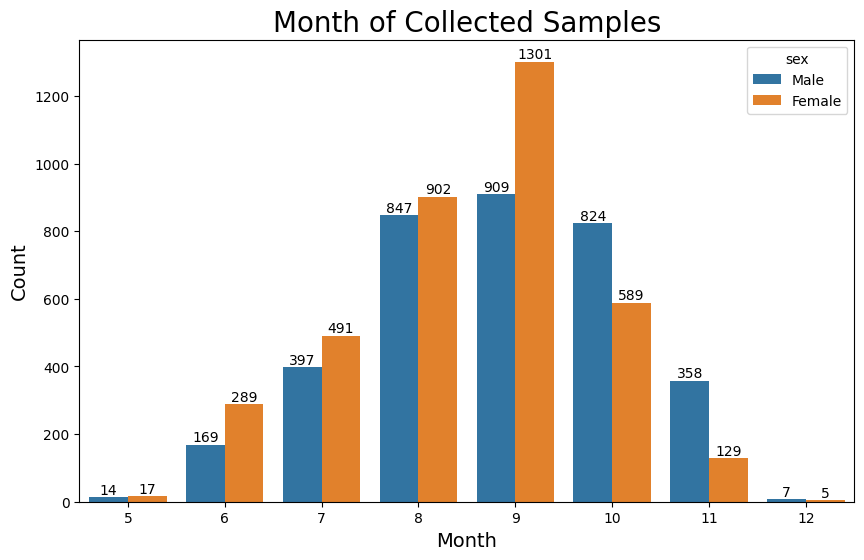

In [26]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=hsv_head, x='month', hue='sex')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Month of Collected Samples", fontsize=20)
plt.xlabel("Month", fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()


# Correlation between Latitude and V Channel

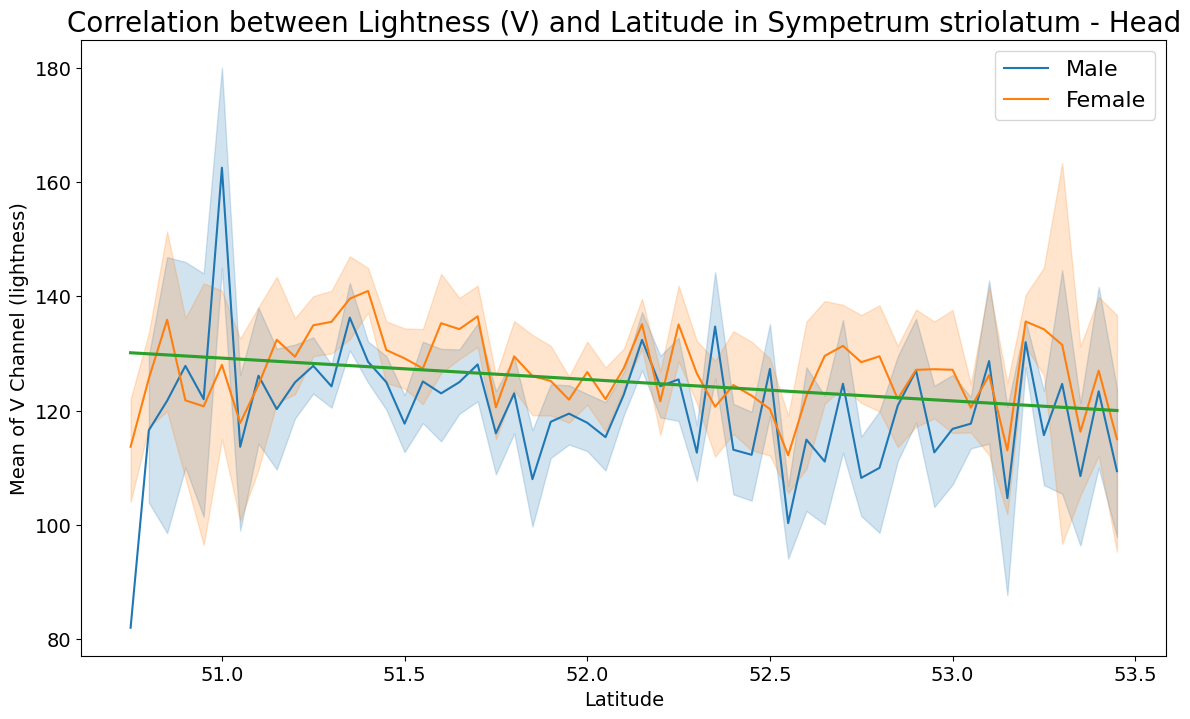

In [ ]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=hsv_head, x="decimalLatitude", y="V_Channel", hue="sex")
sns.regplot(data=hsv_head, x="decimalLatitude", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Lightness (V) and Latitude in Sympetrum striolatum - Head", fontsize=20)
plt.xlabel("Latitude", fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()


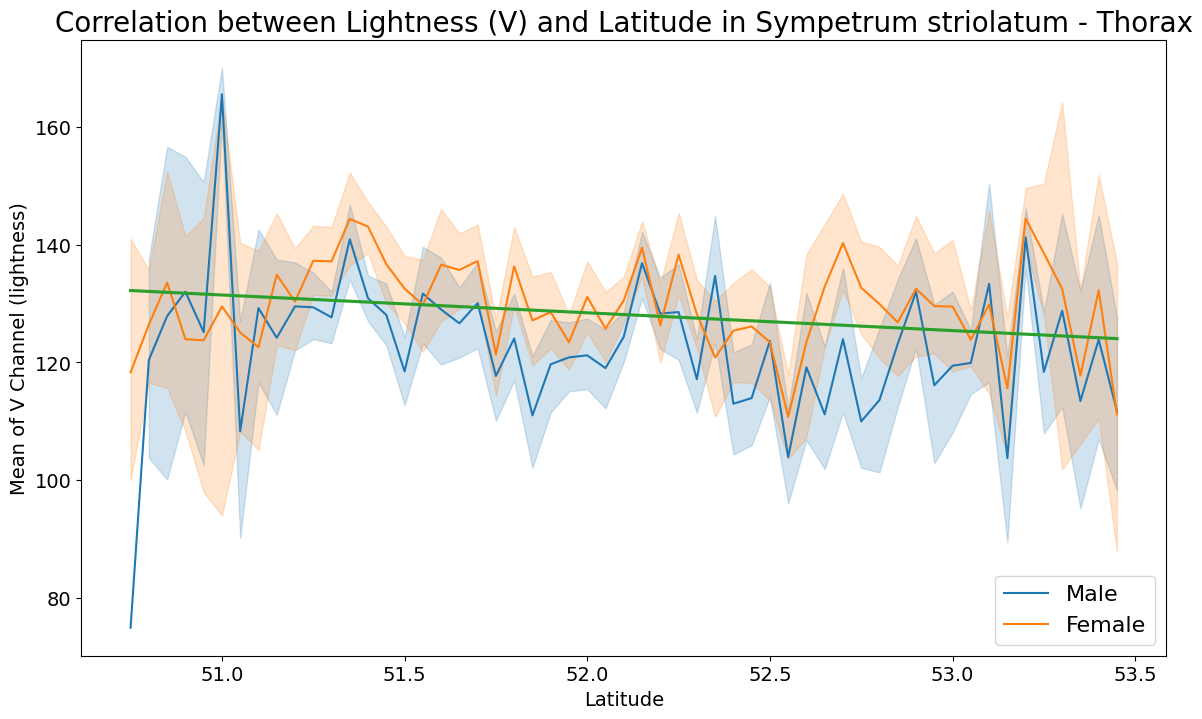

In [50]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=hsv_thorax, x="decimalLatitude", y="V_Channel", hue="sex")
sns.regplot(data=hsv_thorax, x="decimalLatitude", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Lightness (V) and Latitude in Sympetrum striolatum - Thorax", fontsize=20)
plt.xlabel("Latitude", fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()


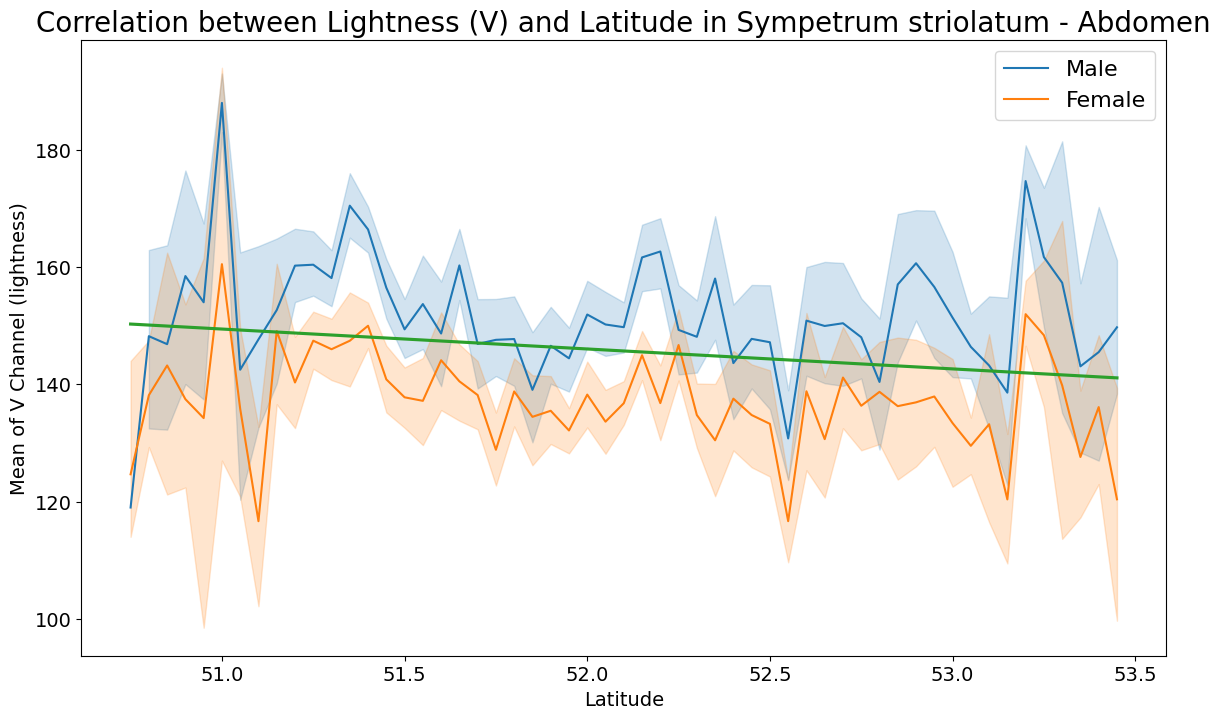

In [51]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=hsv_abdomen, x="decimalLatitude", y="V_Channel", hue="sex")
sns.regplot(data=hsv_abdomen, x="decimalLatitude", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Lightness (V) and Latitude in Sympetrum striolatum - Abdomen", fontsize=20)
plt.xlabel("Latitude", fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()


# Correlation between Hour and V Channel

## Normal Hours

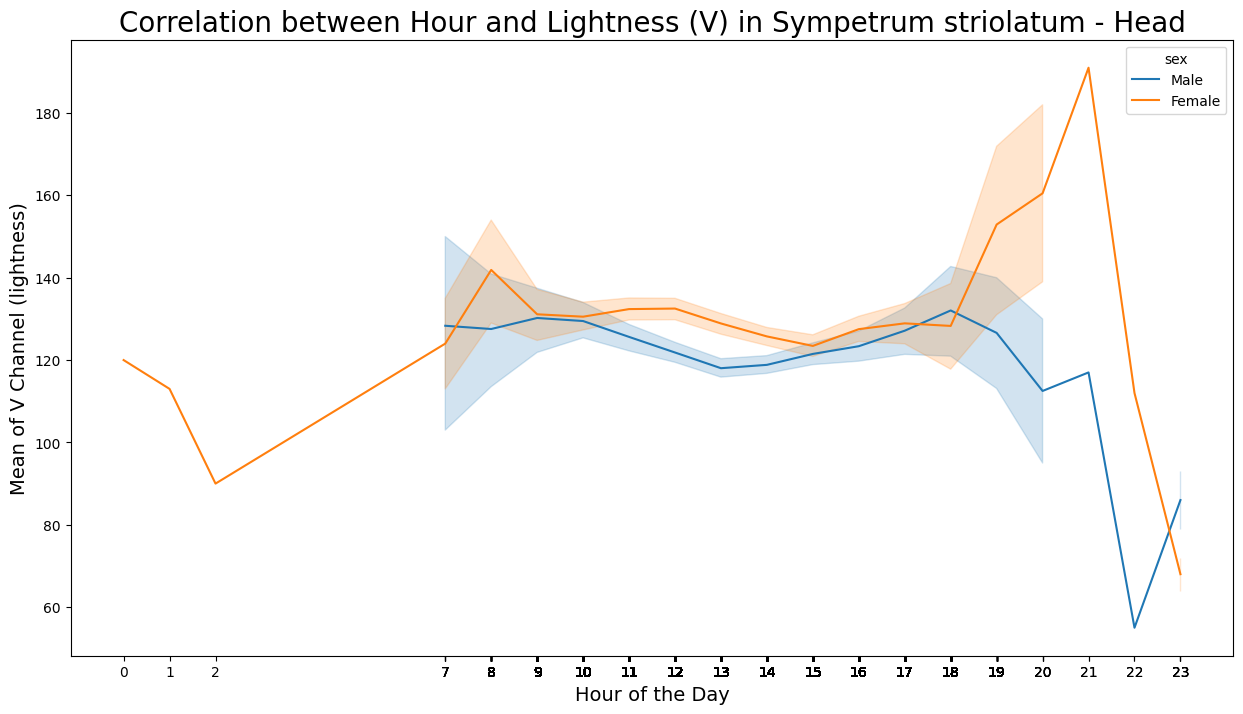

In [30]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_head, x="hour", y="V_Channel", hue="sex")
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Head", fontsize=20)
plt.xticks(hsv_head.hour.values)
plt.xlabel("Hour of the Day", fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.show()


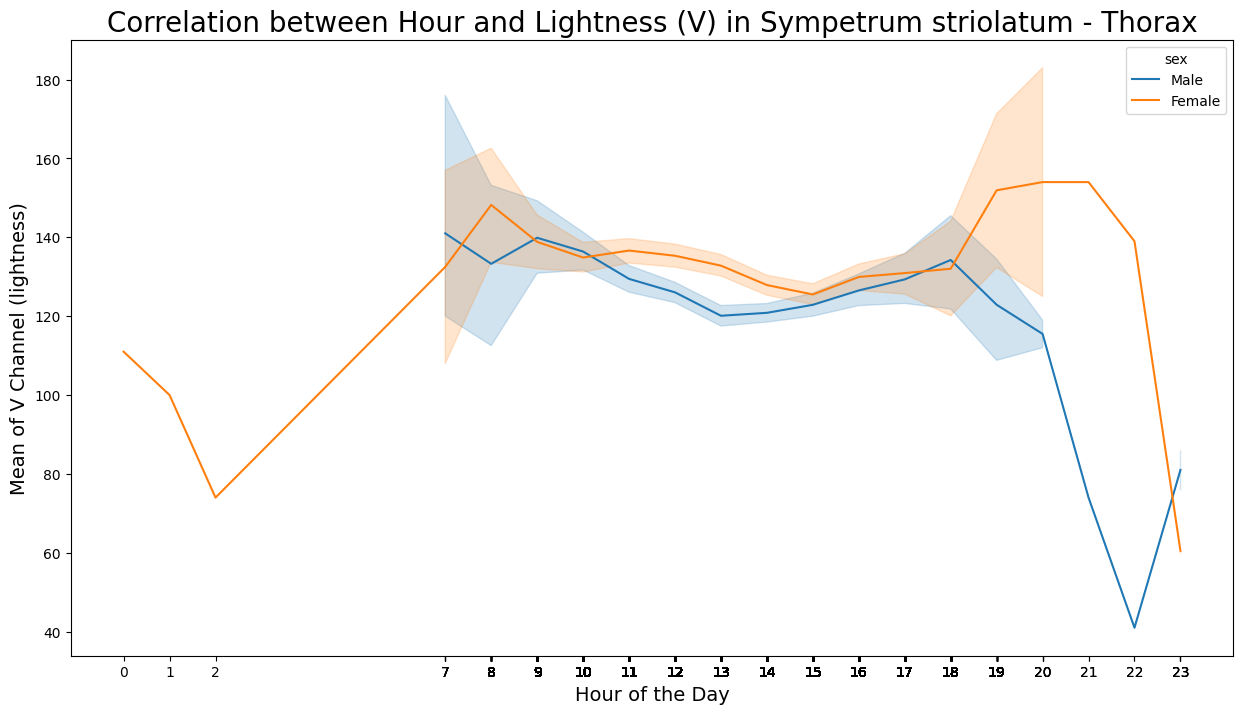

In [31]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_thorax, x="hour", y="V_Channel", hue="sex")
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Thorax", fontsize=20)
plt.xticks(hsv_thorax.hour.values)
plt.xlabel("Hour of the Day", fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.show()


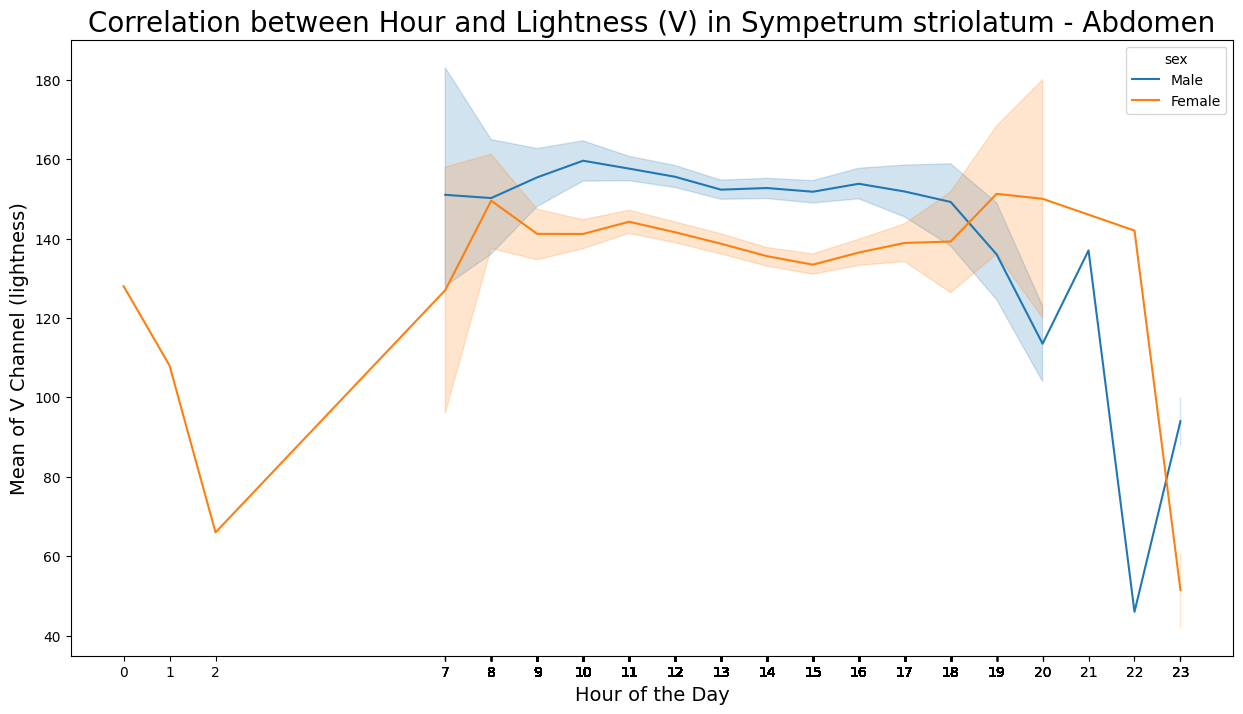

In [32]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_abdomen, x="hour", y="V_Channel", hue="sex")
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Abdomen", fontsize=20)
plt.xticks(hsv_abdomen.hour.values)
plt.xlabel("Hour of the Day", fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.show()


## Adjusted Hours

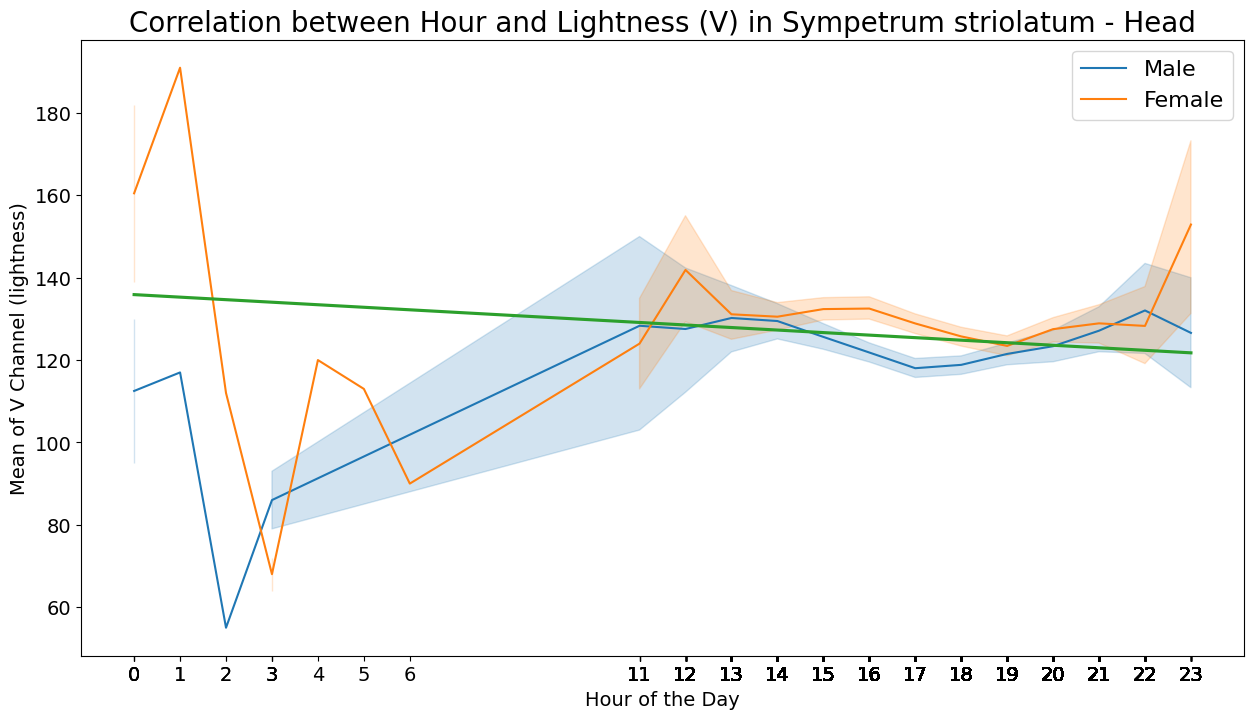

In [62]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_head, x="adjusted_hour", y="V_Channel", hue="sex")
sns.regplot(data=hsv_head, x="adjusted_hour", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Head", fontsize=20)
plt.xlabel("Hour of the Day", fontsize=14)
plt.xticks(hsv_head.adjusted_hour.values, fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()

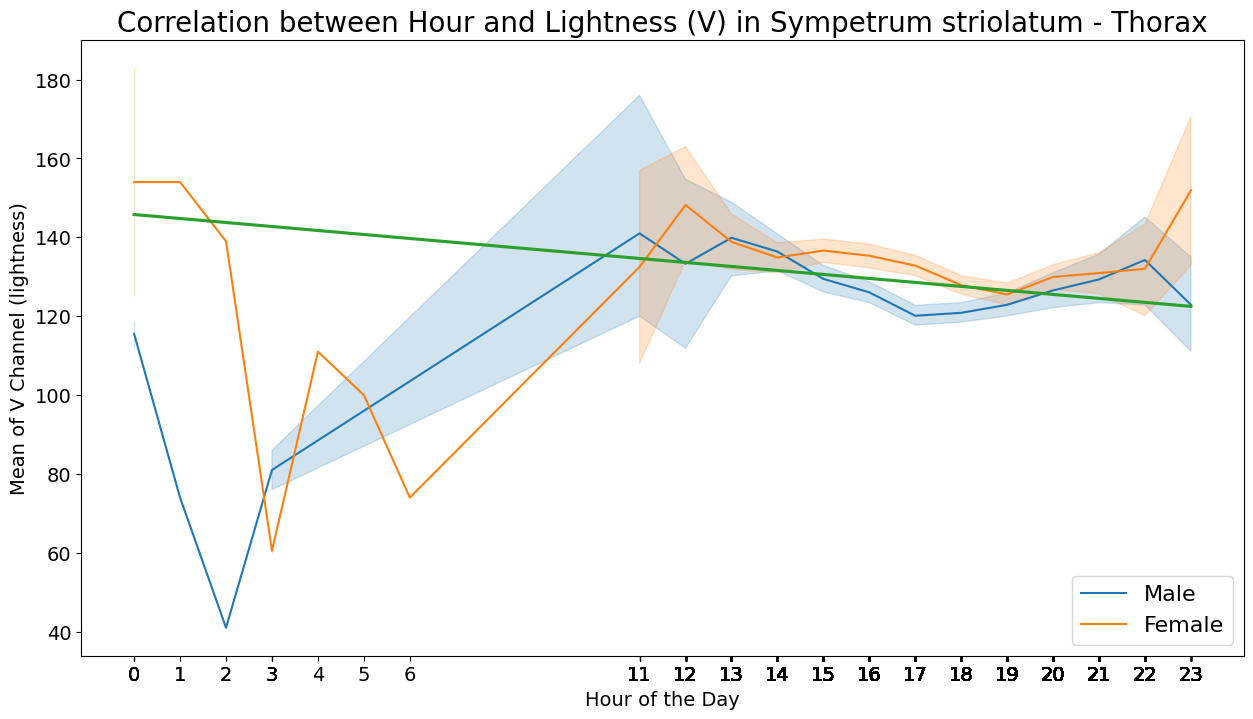

In [61]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_thorax, x="adjusted_hour", y="V_Channel", hue="sex")
sns.regplot(data=hsv_thorax, x="adjusted_hour", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Thorax", fontsize=20)
plt.xlabel("Hour of the Day", fontsize=14)
plt.xticks(hsv_thorax.adjusted_hour.values, fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()


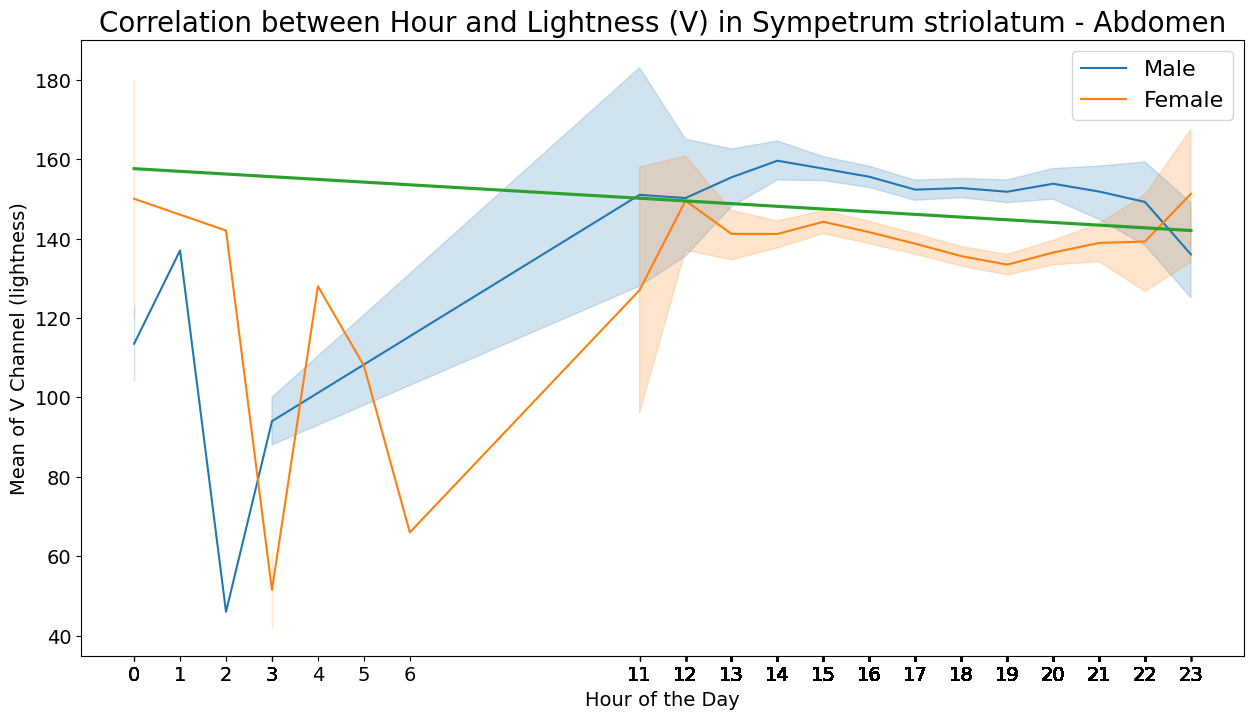

In [63]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=hsv_abdomen, x="adjusted_hour", y="V_Channel", hue="sex")
sns.regplot(data=hsv_abdomen, x="adjusted_hour", y="V_Channel", scatter=False, ci=None)
plt.title("Correlation between Hour and Lightness (V) in Sympetrum striolatum - Abdomen", fontsize=20)
plt.xlabel("Hour of the Day", fontsize=14)
plt.xticks(hsv_abdomen.adjusted_hour.values, fontsize=14)
plt.ylabel('Mean of V Channel (lightness)', fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.show()

# Pearson Correlation between V Channel and Latitude

In [36]:
corr, pval = pearsonr(hsv_head['decimalLatitude'], hsv_head['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_head['decimalLatitude'], hsv_head['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.07604
p-value of Pearson: 9.03270e-11
Rho value of Spearman: -0.07983
p-value of Spearman: 1.00323e-11


In [37]:
corr, pval = pearsonr(hsv_thorax['decimalLatitude'], hsv_thorax['V_Channel']) 
rho_value, p_val_r = spearmanr(hsv_thorax['decimalLatitude'], hsv_thorax['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.05486
p-value of Pearson: 2.97016e-06
Rho value of Spearman: -0.06111
p-value of Spearman: 1.92307e-07


In [38]:
corr, pval = pearsonr(hsv_abdomen['decimalLatitude'], hsv_abdomen['V_Channel']) 
rho_value, p_val_r = spearmanr(hsv_abdomen['decimalLatitude'], hsv_abdomen['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.06283
p-value of Pearson: 8.63263e-08
Rho value of Spearman: -0.07440
p-value of Spearman: 2.27792e-10


# Pearson Correlation between Hour of Day and V Channel

## Normal Hours

In [39]:
corr, pval = pearsonr(hsv_head['hour'], hsv_head['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_head['hour'], hsv_head['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.05418
p-value of Pearson: 3.93291e-06
Rho value of Spearman: -0.05705
p-value of Spearman: 1.17494e-06


In [40]:
corr, pval = pearsonr(hsv_thorax['hour'], hsv_thorax['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_thorax['hour'], hsv_thorax['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.08086
p-value of Pearson: 5.42833e-12
Rho value of Spearman: -0.08310
p-value of Spearman: 1.38143e-12


In [41]:
corr, pval = pearsonr(hsv_abdomen['hour'], hsv_abdomen['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_abdomen['hour'], hsv_abdomen['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.06735
p-value of Pearson: 9.52325e-09
Rho value of Spearman: -0.07090
p-value of Spearman: 1.51872e-09


## Adjusted Hours

In [42]:
corr, pval = pearsonr(hsv_head['adjusted_hour'], hsv_head['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_head['adjusted_hour'], hsv_head['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.04341
p-value of Pearson: 2.18664e-04
Rho value of Spearman: -0.05433
p-value of Spearman: 3.69492e-06


In [43]:
corr, pval = pearsonr(hsv_thorax['adjusted_hour'], hsv_thorax['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_thorax['adjusted_hour'], hsv_thorax['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.06394
p-value of Pearson: 5.09281e-08
Rho value of Spearman: -0.07939
p-value of Spearman: 1.30040e-11


In [44]:
corr, pval = pearsonr(hsv_abdomen['adjusted_hour'], hsv_abdomen['V_Channel'])
rho_value, p_val_r = spearmanr(hsv_abdomen['adjusted_hour'], hsv_abdomen['V_Channel'])

print(f"Pearson correlation: {corr:.5f}")
print(f"p-value of Pearson: {pval:.5e}")
print(f"Rho value of Spearman: {rho_value:.5f}")
print(f"p-value of Spearman: {p_val_r:.5e}")

Pearson correlation: -0.04352
p-value of Pearson: 2.10521e-04
Rho value of Spearman: -0.06573
p-value of Spearman: 2.13462e-08
